# Análise Comparativa de Modelos

**Projeto:** Projeto ANEEL - Energia em Risco: Análise de Dados de Continuidade Elétrica e Previsão de Risco Regulatório

**Metodologia:** CRISP-DM

**Período de Análise:** 2021 – 2025

---

## Visão Geral

Este notebook consolida a **Fase 4 do CRISP-DM - Modelagem (Modeling)** com o consumo da base preparada, a definição das métricas, do modelo de baseline e dos modelos candidatos. Também serão realizados o treinamento dos modelos, o ajuste de hiperparêmetros e a análise comparativa dos modelos otimizados. 

---

## Sumário

1. Configurações do ambiente  
2. Objetivo da modelagem  
3. Carregamento da base preparada  
4. Métricas de avaliação  
5. Baseline e estratégia de avaliação  
6. Modelos candidatos  
7. Treinamento e comparação inicial  
8. Ajuste de limiares na validação  
9. Ajuste temporal dos hiperparâmetros  
10. Seleção do campeão e validação final  
11. Limitações e conclusão 

---

## 1. Configurações do ambiente

Esta etapa mantém o padrão de configuração utilizado nos notebooks anteriores: ambiente `.venv`, caminhos derivados de `PROJECT_ROOT`, opções de visualização e `RANDOM_STATE` fixo para permitir a reprodução dos experimentos.

In [ ]:
# Importações e configurações do ambiente
import os
import sys
from pathlib import Path
import time

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
import joblib

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scipy.stats import loguniform

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.data.constants import ANO_INICIO, ANO_FIM

MODEL_DATA_DIR = PROCESSED_DIR / "modeling"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METADATA_DIR = PROJECT_ROOT / "docs" / "metadata"
MODEL_DIR = PROJECT_ROOT / "models"

INITIAL_RESULTS_FILE = METADATA_DIR / "model_initial_training_results.csv"
TUNING_RESULTS_FILE = METADATA_DIR / "model_tuning_training_results.csv"
OPERATIONAL_RESULTS_FILE = METADATA_DIR / "model_operational_comparison.csv"

os.makedirs(MODEL_DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:.8f}")

print(f"Período analisado: {ANO_INICIO}-{ANO_FIM}")
print(f"RANDOM_STATE: {RANDOM_STATE}")

Período analisado: 2021-2025
RANDOM_STATE: 42


In [101]:
# Definindo a paleta de cores
colors = ["#959300", "#01719f", "#004e72"]
sns.set_theme(style="whitegrid")
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette(colors))

custom_cmap = LinearSegmentedColormap.from_list("custom_colors", colors[::-1])
custom_cmap.set_under(colors[::-1][0])
custom_cmap.set_bad(colors[::-1][0])

---

## 2. Objetivo da modelagem

Comparar modelos de classificação capazes de prever o `alvo`, isto é, a ocorrência de transgressão regulatória no período seguinte para cada conjunto e indicador.

1. **Entradas esperadas do notebook 04:** `X_train`, `y_train`, `X_validation`, `y_validation`, `X_test` e `y_test`.

2. **Partições:** Treino `(2021–2023)`, validação `(2024)` e teste `(2025)`. A ordem temporal deve ser preservada em todas as avaliações.

3. **Modelo Baseline:** Classificador simples e interpretável, utilizado como referência mínima.

4. **Modelos Candidatos:** Modelos lineares e baseados em bagging e boosting, treinados com tratamento do desbalanceamento e validação cruzada temporal (TimeSeriesSplit).

5. **Métricas Prioritárias:** `Precision`, `Recall`, `F1-score`, `PR-AUC` e `Matriz de Confusão`. A acurácia não será usada como critério principal devido à raridade das transgressões.

6. **Critério de Seleção:** Escolher o modelo que ofereça melhor equilíbrio entre detecção das transgressões, precisão dos alertas, estabilidade temporal e interpretabilidade operacional.

---

## 3. Carregamento da base preparada

As matrizes são carregadas a partir dos Parquets exportados pelo [notebook 04_data_preparation.ipynb](04_data_preparation.ipynb). O carregamento valida a existência das seis entradas esperadas, o alinhamento das colunas e a ausência de nulos nos atributos.

In [102]:
# Carregamento e validação das matrizes exportadas pelo notebook 04

required_model_files = [
    MODEL_DATA_DIR / "X_train.parquet",
    MODEL_DATA_DIR / "X_validation.parquet",
    MODEL_DATA_DIR / "X_test.parquet",
    MODEL_DATA_DIR / "y_train.parquet",
    MODEL_DATA_DIR / "y_validation.parquet",
    MODEL_DATA_DIR / "y_test.parquet",
    MODEL_DATA_DIR / "modeling_metadata.json",
]

# Verifica se todos os arquivos necessários existem
missing_model_files = [str(path) for path in required_model_files if not path.exists()]
if missing_model_files:
    raise FileNotFoundError(
        "Matrizes ou metadados ausentes. Execute a exportação no notebook 04:\n"
        + "\n".join(missing_model_files)
    )

# Carregamento das matrizes de treino, validação e teste, bem como os metadados do modelo
X_train = pd.read_parquet(required_model_files[0])
X_validation = pd.read_parquet(required_model_files[1])
X_test = pd.read_parquet(required_model_files[2])
y_train = pd.read_parquet(required_model_files[3])["alvo"]
y_validation = pd.read_parquet(required_model_files[4])["alvo"]
y_test = pd.read_parquet(required_model_files[5])["alvo"]
modeling_metadata = pd.read_json(required_model_files[6]).iloc[0].to_dict()
scale_pos_weight = float(modeling_metadata["scale_pos_weight"])

assert list(X_train.columns) == list(X_validation.columns) == list(X_test.columns)
assert int(X_train.isna().sum().sum()) == 0
assert int(X_validation.isna().sum().sum()) == 0
assert int(X_test.isna().sum().sum()) == 0
assert int(y_train.sum()) == int(modeling_metadata["train_positives"])
assert int(len(y_train) - y_train.sum()) == int(modeling_metadata["train_negatives"])

# Resumo das dimensões das matrizes de treino, validação e teste
model_input_summary = pd.DataFrame(
    [
        {
            "particao": "treino",
            "observacoes": len(X_train),
            "atributos": X_train.shape[1],
            "transgressoes": int(y_train.sum()),
        },
        {
            "particao": "validacao",
            "observacoes": len(X_validation),
            "atributos": X_validation.shape[1],
            "transgressoes": int(y_validation.sum()),
        },
        {
            "particao": "teste",
            "observacoes": len(X_test),
            "atributos": X_test.shape[1],
            "transgressoes": int(y_test.sum()),
        },
    ]
)

display(model_input_summary)
print(f"scale_pos_weight carregado: {scale_pos_weight:.4f}")

,particao,observacoes,atributos,transgressoes
0,treino,223184,129,70
1,validacao,75072,129,14
2,teste,69026,129,6


scale_pos_weight carregado: 3187.3429


---

## 4. Métricas de avaliação

A avaliação combina métricas com diferentes sensibilidades ao desbalanceamento, rigor estatístico na calibração de riscos e tolerância a alarmes falsos:

1. **Precision (Precisão)**  

    - **O que mede:** A proporção de verdadeiras transgressões entre todas as instâncias que o modelo classificou como transgressão ($\frac{TP}{TP + FP}$).

    - **Por que é essencial?** Mede a eficiência operacional do modelo.

2. **Recall (Sensibilidade)**  

    - **O que mede:** A proporção de transgressões reais que foram identificadas com sucesso pelo modelo ($\frac{TP}{TP + FN}$).

    - **Por que é essencial?** É a métrica de proteção regulatória. Um recall baixo significa que violações de DEC/FEC ocorrerão sem aviso prévio, gerando multas, compensações financeiras aos consumidores e autuações da ANEEL.

3. **F1-Score**  

    - **O que mede:** A média harmônica entre Precision e Recall ($2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$), atribuindo peso idêntico a ambos.

    - **Por que é essencial?** Fornece um resumo único do equilíbrio entre alarmes falsos e transgressões não detectadas em um limiar de corte fixo ($0{,}50$).

4. **ROC-AUC**  

    - **O que mede:** A probabilidade de o classificador atribuir um score mais alto a um conjunto com transgressão sorteado aleatoriamente do que a um conjunto sem transgressão.

    - **Por que é essencial?** Serve como benchmark padrão da literatura técnica e avalia a separabilidade global das classes ao longo de múltiplos limiares de falso positivo.

5. **PR-AUC**  

    - **O que mede:** O desempenho agregado do modelo integrando todos os limiares de decisão possíveis exclusivamente sobre a classe positiva (minoritária).

    - **Por que é essencial?** É o critério principal para seleção e ranqueamento dos modelos. Em bases com forte desbalanceamento, reflete a capacidade discriminatória real sem ser mascarada pelo volume massivo de instâncias sem transgressão.

6. **Matriz de Confusão**  

    - **O que mede:** O mapeamento quantitativo absoluto das predições cruzadas com a realidade, dividido em Verdadeiros Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) e Verdadeiros Positivos (TP).
    
    - **Por que é essencial?** Permite auditar os volumes brutos de erros e acertos em cada partição temporal, possibilitando traduzir diretamente a acurácia técnica do algoritmo.

---

## 5. Baseline e estratégia de avaliação

O baseline sempre prevê a classe majoritária observada no treino. Ele não representa um modelo operacional, mas estabelece o desempenho mínimo que os modelos candidatos precisam superar.

A avaliação será feita na validação, usando as métricas adequadas ao evento raro. A matriz de confusão mostrará se o modelo consegue identificar transgressões ou apenas reproduz a classe dominante.

In [103]:
# Baseline de classe majoritária e funções de avaliação
def evaluate_classifier(model_name, y_true, predictions, scores):
    return {
        "modelo": model_name,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1_score": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
    }


def compute_pr_curve(y_true, scores):
    precision_curve, recall_curve, thresholds = precision_recall_curve(
        y_true,
        scores,
    )

    f1_curve = (
        2
        * precision_curve[:-1]
        * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + np.finfo(float).eps)
    )

    return precision_curve, recall_curve, thresholds, f1_curve


def select_decision_threshold(
    y_true,
    scores,
    target_recall=None,
    metric="f1",
):
    precision_curve, recall_curve, thresholds, f1_curve = compute_pr_curve(
        y_true,
        scores,
    )

    if target_recall is None:
        best_index = int(np.argmax(f1_curve))
        return {
            "threshold": float(thresholds[best_index]),
            "precision": float(precision_curve[best_index]),
            "recall": float(recall_curve[best_index]),
            "f1_score": float(f1_curve[best_index]),
        }

    feasible = recall_curve[:-1] >= target_recall

    if feasible.any():
        feasible_indices = np.flatnonzero(feasible)

        if metric == "precision":
            best_index = feasible_indices[
                np.argmax(precision_curve[:-1][feasible_indices])
            ]
        else:
            best_index = feasible_indices[np.argmax(f1_curve[feasible_indices])]
    else:
        best_index = int(np.argmax(recall_curve[:-1]))

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(precision_curve[best_index]),
        "recall": float(recall_curve[best_index]),
        "f1_score": float(f1_curve[best_index]),
    }


baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_validation)
baseline_scores = baseline_model.predict_proba(X_validation)[:, 1]

baseline_metrics = pd.DataFrame(
    [
        evaluate_classifier(
            "baseline_classe_majoritaria",
            y_validation,
            baseline_predictions,
            baseline_scores,
        )
    ]
)
baseline_confusion = confusion_matrix(y_validation, baseline_predictions)

display(baseline_metrics)

print(f"Matriz de confusão: baseline_classe_majoritaria")
display(
    pd.DataFrame(
        index=["real_0", "real_1"],
        columns=["predito_0", "predito_1"],
        data=baseline_confusion,
    )
)

,modelo,precision,recall,f1_score,roc_auc,pr_auc
0,baseline_classe_majoritaria,0.00000000,0.00000000,0.00000000,0.50000000,0.00018649


Matriz de confusão: baseline_classe_majoritaria


,predito_0,predito_1
real_0,75058,0
real_1,14,0


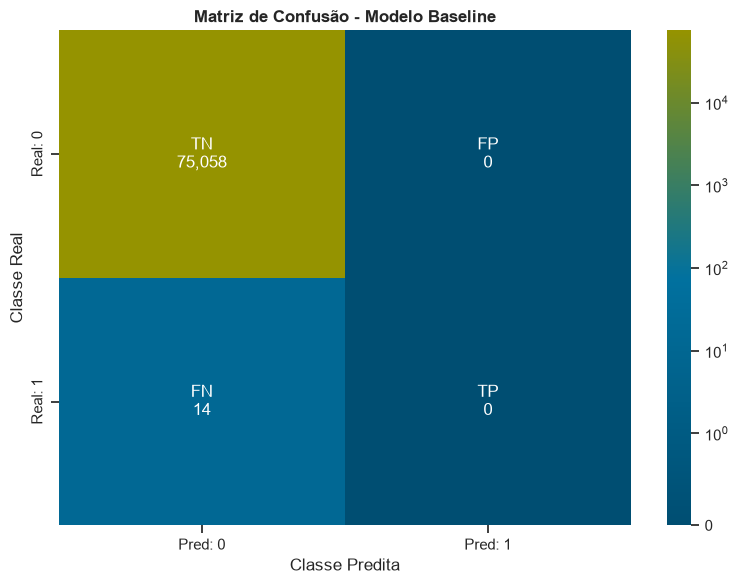

Gráfico salvo com sucesso em: ..\reports\figures\model_baseline_confusion_matrix.png


In [ ]:
# Matriz de confusão do modelo baseline

full_path = os.path.join(FIGURES_DIR, "model_baseline_confusion_matrix.png")
relative_path = os.path.relpath(full_path)

tn, fp, fn, tp = baseline_confusion.ravel()

labels = [
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"],
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    baseline_confusion,
    annot=labels,
    fmt="",
    cmap=custom_cmap,
    norm=SymLogNorm(
        linthresh=1.0,
        vmin=0,
        vmax=baseline_confusion.max(),
        base=10,
    ),
    cbar=True,
    xticklabels=["Pred: 0", "Pred: 1"],
    yticklabels=["Real: 0", "Real: 1"],
)
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.title("Matriz de Confusão - Modelo Baseline", fontweight="bold")

plt.tight_layout()
plt.savefig(relative_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_path}")

In [105]:
# Análise do modelo baseline
tn = baseline_confusion[0, 0]
fp = baseline_confusion[0, 1]
fn = baseline_confusion[1, 0]
tp = baseline_confusion[1, 1]
total_amostras = tn + fp + fn + tp

row_baseline = baseline_metrics.loc[
    baseline_metrics["modelo"] == "baseline_classe_majoritaria"
].iloc[0]

precision_val = row_baseline["precision"]
recall_val = row_baseline["recall"]
f1_val = row_baseline["f1_score"]
roc_auc_val = row_baseline["roc_auc"]
pr_auc_val = row_baseline["pr_auc"]
acuracia_val = (tn + tp) / total_amostras

display(
    Markdown(
        f"* O modelo classifica todas as **{total_amostras:,}** instâncias como pertencentes à classe negativa (`predito_0`), não gerando"
        f" nenhum falso positivo (`FP = {fp:,}`), mas falhando em detectar qualquer evento de interesse (`predito_1 = {tp + fp:,}`).\n\n"
        f"* O classificador atinge **Recall de {recall_val:.2%}** e **Precisão de {precision_val:.2%}** (com **$F_1$-Score = {f1_val:.4f}**),"
        f" resultando em **{fn:,} falsos negativos** para as **{fn + tp:,} ocorrências reais** da classe positiva (`real_1`).\n\n"
        f"* A métrica **ROC-AUC fica em {roc_auc_val:.2f}**, caracterizando ausência de discriminação, enquanto o **PR-AUC** converge para"
        f" **{pr_auc_val:.8f}** (equivalente à presença do evento raro na base: **{((fn + tp) / total_amostras):.4%}**).\n\n"
        f"* Apesar de apresentar uma acurácia aparente de **{acuracia_val:.4%}** decorrente do desbalanceamento extremo,"
        f" o modelo é operacionalmente nulo por não capturar nenhum verdadeiro positivo (`TP = {tp:,}`)."
    )
)

* O modelo classifica todas as **75,072** instâncias como pertencentes à classe negativa (`predito_0`), não gerando nenhum falso positivo (`FP = 0`), mas falhando em detectar qualquer evento de interesse (`predito_1 = 0`).

* O classificador atinge **Recall de 0.00%** e **Precisão de 0.00%** (com **$F_1$-Score = 0.0000**), resultando em **14 falsos negativos** para as **14 ocorrências reais** da classe positiva (`real_1`).

* A métrica **ROC-AUC fica em 0.50**, caracterizando ausência de discriminação, enquanto o **PR-AUC** converge para **0.00018649** (equivalente à presença do evento raro na base: **0.0186%**).

* Apesar de apresentar uma acurácia aparente de **99.9814%** decorrente do desbalanceamento extremo, o modelo é operacionalmente nulo por não capturar nenhum verdadeiro positivo (`TP = 0`).

---

## 6. Modelos candidatos

A comparação combina modelos com diferentes níveis de interpretabilidade, capacidade de capturar não linearidades e custo computacional. Foram escolhidos algoritmos de três famílias distintas: linear, bagging e boosting.


1. **Regressão logística:** 

    - **Família:** Modelo Linear.

    - **Função:** referência interpretável e base de comparação.

2. **ExtraTreesClassifier:** 

    - **Família:** Ensemble por Bagging.

    - **Função:** Capturar interações não lineares com menor variância do que árvores tradicionais.

3. **LightGBM:** 

    - **Família:** Gradient Boosting.

    - **Função:** Alta velocidade e performance em dados tabulares com classe rara.

4. **XGBoost:** 

    - **Família:** Gradient Boosting.

    - **Função:** Forte capacidade de modelagem de padrões complexos com regularização.

5. **CatBoost:** 
    
    - **Família:** Gradient Boosting (árvores simétricas).

    - **Função:** Robustez em dados tabulares e controle de viés com tratamento do desbalanceamento.

A escolha desses modelos permite comparar não apenas desempenho, mas também estabilidade operacional, custo de treinamento e capacidade de separação do evento raro.

In [106]:
# Definição dos modelos candidatos com seus respectivos hiperparâmetros
candidate_models = {
    "logistic_regression": LogisticRegression(
        solver="saga",
        l1_ratio=0.5,
        class_weight="balanced",
        max_iter=1000,
        tol=1e-2,
        random_state=RANDOM_STATE,
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "lightgbm": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=150,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "catboost": CatBoostClassifier(
        scale_pos_weight=scale_pos_weight,
        iterations=150,
        verbose=0,
        random_state=RANDOM_STATE,
        thread_count=-1,
    ),
}


# Função para identificar o tratamento de desbalanceamento aplicado em cada modelo
def get_imbalance_treatment(model):
    params = model.get_params()
    if params.get("class_weight") is not None:
        return f"class_weight='{params['class_weight']}'"
    if params.get("scale_pos_weight") is not None:
        weight_val = params["scale_pos_weight"]
        return f"scale_pos_weight={weight_val:.4f}"
    return "Nenhum"


# DataFrame com as especificações dos modelos candidatos
model_specs = pd.DataFrame(
    [
        {
            "modelo": model_name,
            "classe": type(model).__name__,
            "tratamento_desbalanceamento": get_imbalance_treatment(model),
        }
        for model_name, model in candidate_models.items()
    ]
)

display(model_specs)

,modelo,classe,tratamento_desbalanceamento
0,logistic_regression,LogisticRegression,class_weight='balanced'
1,extra_trees,ExtraTreesClassifier,class_weight='balanced_subsample'
2,lightgbm,LGBMClassifier,scale_pos_weight=3187.3429
3,xgboost,XGBClassifier,scale_pos_weight=3187.3429
4,catboost,CatBoostClassifier,scale_pos_weight=3187.3429


---

## 7. Treinamento e comparação inicial

Os modelos candidatos foram treinados somente com `X_train` e `y_train`. Os modelos de boosting receberam o `scale_pos_weight` calculado no [04_data_preparation.ipynb](04_data_preparation.ipynb), enquanto os modelos do scikit-learn utilizaram `class_weight` quando essa opção era suportada.

A comparação inicial foi feita na validação para observar o comportamento dos modelos em um cenário realista de desbalanceamento, sem alteração do limiar de classificação. O foco desta etapa foi verificar a ordenação de risco e a separação do evento raro antes do ajuste operacional.


In [ ]:
# Treinamento, inferência e avaliação dos modelos candidatos

full_path = INITIAL_RESULTS_FILE
relative_path = os.path.relpath(full_path)

trained_models = {}
validation_predictions = {}
validation_scores = {}
validation_metrics = []

for model_name, model in candidate_models.items():
    print(f"Treinando: {model_name}")

    # 1. Treinamento (fit)
    t0_fit = time.perf_counter()
    model.fit(X_train, y_train)
    tempo_treino_s = time.perf_counter() - t0_fit

    # 2. Inferências (predict)
    t0_infer = time.perf_counter()
    predictions = model.predict(X_validation)
    scores = model.predict_proba(X_validation)[:, 1]
    tempo_pred_s = time.perf_counter() - t0_infer

    # 3. Armazenamento dos resultados
    trained_models[model_name] = model
    validation_predictions[model_name] = predictions
    validation_scores[model_name] = scores

    metrics_dict = evaluate_classifier(model_name, y_validation, predictions, scores)
    metrics_dict["tempo_treino_s"] = round(tempo_treino_s, 2)
    metrics_dict["tempo_pred_s"] = round(tempo_pred_s, 2)

    validation_metrics.append(metrics_dict)
    print(f"-> Concluído em {tempo_treino_s:.1f}s")

# 4. Consolidação dos resultados ordenada pelo PR-AUC
validation_metrics = pd.DataFrame(validation_metrics).sort_values(
    "pr_auc",
    ascending=False,
)
display(validation_metrics)

validation_metrics.to_csv(
    full_path,
    index=False,
)

print(f"Tabela salva com sucesso em: {relative_path}")

Treinando: logistic_regression
-> Concluído em 84.6s
Treinando: extra_trees
-> Concluído em 12.0s
Treinando: lightgbm
-> Concluído em 1.9s
Treinando: xgboost
-> Concluído em 13.1s
Treinando: catboost
-> Concluído em 7.9s


,modelo,precision,recall,f1_score,roc_auc,pr_auc,tempo_treino_s,tempo_pred_s
3,xgboost,0.00000000,0.00000000,0.00000000,0.79466641,0.00173896,13.11000000,0.38000000
0,logistic_regression,0.00085646,0.35714286,0.00170882,0.60066215,0.00104418,84.56000000,0.12000000
1,extra_trees,0.00168919,0.14285714,0.00333890,0.73887146,0.00077345,12.05000000,0.72000000
2,lightgbm,0.00113766,0.28571429,0.00226629,0.61946190,0.00045825,1.87000000,0.17000000
4,catboost,0.00000000,0.00000000,0.00000000,0.58732009,0.00042198,7.94000000,0.12000000


Tabela salva com sucesso em: ..\docs\metadata\model_initial_training_results.csv


In [108]:
# Análise comparativa dos modelos candidatos
initial_csv_path = str(INITIAL_RESULTS_FILE)

df_initial = pd.read_csv(initial_csv_path).set_index("modelo")

xgb = df_initial.loc["xgboost"]
cat = df_initial.loc["catboost"]

top_model = df_initial.sort_values("pr_auc", ascending=False).iloc[0]
faster_model = df_initial.sort_values("tempo_treino_s").iloc[0]
slower_model = df_initial.sort_values("tempo_treino_s", ascending=False).iloc[0]
worst_pred = df_initial.sort_values("tempo_pred_s", ascending=False).iloc[0]

speed_factor = slower_model["tempo_treino_s"] / max(
    faster_model["tempo_treino_s"], 1e-4
)

display(
    Markdown(
        f"* Tanto o **XGBoost** quanto o **CatBoost** registraram Precisão, Recall e F1-Score nulos, "
        f" demonstrando que o limiar de decisão padrão `(0.5)` não é adequado para esses modelos.\n\n"
        f"* Apesar do F1-Score nulo no limiar padrão, o **{top_model.name}** "
        f"atingiu os maiores valores de **ROC-AUC ({top_model['roc_auc']:.4f})** e **PR-AUC ({top_model['pr_auc']:.6f})** provando ter a"
        f"melhor capacidade de ordenação de risco entre todos os concorrentes.\n\n"
        f"* O ROC-AUC apresentou patamares otimistas entre **{df_initial['roc_auc'].min():.3f} e {df_initial['roc_auc'].max():.3f}** "
        f"devido ao volume de verdadeiros negativos, enquanto o PR-AUC variou entre **{df_initial['pr_auc'].min():.6f} e {df_initial['pr_auc'].max():.6f}**, "
        f"refletindo a real severidade do evento raro.\n\n"
        f"* O **{faster_model.name}** destacou-se pela velocidade de treino (**{faster_model['tempo_treino_s']:.2f} s**), "
        f"sendo cerca de **{speed_factor:.1f}x mais veloz** que o mais lento (**{slower_model.name}**, com **{slower_model['tempo_treino_s']:.2f} s**), "
        f"enquanto o **{worst_pred.name}** registrou o maior tempo de predição (**{worst_pred['tempo_pred_s']:.2f} s**)."
    )
)

* Tanto o **XGBoost** quanto o **CatBoost** registraram Precisão, Recall e F1-Score nulos,  demonstrando que o limiar de decisão padrão `(0.5)` não é adequado para esses modelos.

* Apesar do F1-Score nulo no limiar padrão, o **xgboost** atingiu os maiores valores de **ROC-AUC (0.7947)** e **PR-AUC (0.001739)** provando ter amelhor capacidade de ordenação de risco entre todos os concorrentes.

* O ROC-AUC apresentou patamares otimistas entre **0.587 e 0.795** devido ao volume de verdadeiros negativos, enquanto o PR-AUC variou entre **0.000422 e 0.001739**, refletindo a real severidade do evento raro.

* O **lightgbm** destacou-se pela velocidade de treino (**1.87 s**), sendo cerca de **45.2x mais veloz** que o mais lento (**logistic_regression**, com **84.56 s**), enquanto o **extra_trees** registrou o maior tempo de predição (**0.72 s**).

---

## 8. Análise de limiares na validação

O limiar de corte padrão `0,50` é conceitualmente inadequado para classes raras, pois tende a suprimir a classe minoritária. Esta etapa explora a curva Precision-Recall (PR-AUC) no conjunto de validação para identificar pontos de operação adequados para diferentes critérios de negócio.

A análise foi conduzida em três cenários:  
1. maximização do F1-Score;  
2. exigência mínima de Recall de 60%;  
3. exigência mínima de Recall de 50%.

Esse procedimento respeita a regra de evitar vazamento de dados: o conjunto de teste foi mantido reservado para a confirmação final.

### 8.1. Cenário 01: Teste com ajuste de limiar do F1-Score

Neste primeiro cenário, busca-se o limiar de decisão que maximiza o $F_1\text{-score}$, que calcula a média harmônica tradicional entre Precisão e Recall. O objetivo é encontrar o ponto ótimo que equilibre matematicamente a capacidade de capturar transgressões com a redução de falsos positivos, assumindo pesos estritamente equivalentes para ambos os tipos de erro.

In [109]:
# PR-AUC com precisão completa e melhor limiar de F1 na validação

threshold_rows = []

for model_name, scores in validation_scores.items():
    threshold_info = select_decision_threshold(
        y_validation,
        scores,
    )

    threshold_rows.append(
        {
            "modelo": model_name,
            "pr_auc": average_precision_score(y_validation, scores),
            "melhor_limiar_f1": threshold_info["threshold"],
            "melhor_precision": threshold_info["precision"],
            "melhor_recall": threshold_info["recall"],
            "melhor_f1": threshold_info["f1_score"],
            "acertos_positivos": int(
                round(threshold_info["recall"] * y_validation.sum())
            ),
        }
    )

threshold_analysis = pd.DataFrame(threshold_rows).sort_values(
    "pr_auc",
    ascending=False,
)

display(
    threshold_analysis.style.format(
        {
            "pr_auc": "{:.8f}",
            "melhor_limiar_f1": "{:.8f}",
            "melhor_precision": "{:.8f}",
            "melhor_recall": "{:.8f}",
            "melhor_f1": "{:.8f}",
        }
    )
)

,modelo,pr_auc,melhor_limiar_f1,melhor_precision,melhor_recall,melhor_f1,acertos_positivos
3,xgboost,0.00173896,0.00658884,0.00877193,0.07142857,0.01562500,1
0,logistic_regression,0.00104418,0.60864651,0.00602410,0.07142857,0.01111111,1
1,extra_trees,0.00077345,0.74020496,0.00371747,0.07142857,0.00706714,1
2,lightgbm,0.00045825,1.00000000,0.00113766,0.28571429,0.00226629,4
4,catboost,0.00042198,0.01285467,0.00280899,0.07142857,0.00540541,1


* Verifica-se uma penalização severa do Recall pelo equilíbrio harmônico. Como o F1-Score atribui peso igual à Precisão e ao Recall, a função de otimização priorizou evitar falsos positivos a qualquer custo. O resultado foi um Recall crítico de apenas **7,14%** na maioria dos modelos, detectando apenas 1 caso positivo no período.

* Os modelos lineares e baseados em *bagging* exigiram limiares elevados (`0,6086` na Regressão Logística e `0,7402` no Extra Trees), enquanto os modelos de *gradient boosting* operaram em patamares muito menores (`0,0066` no XGBoost e `0,0129` no CatBoost), evidenciando diferentes calibrações de probabilidade interna.

* O XGBoost apresentou o melhor equilíbrio de F1-Score (`0,0156`) e a maior área sob a curva (`PR-AUC` de `0,001739`), demonstrando maior estabilidade para separar o ruído na cauda da distribuição em comparação aos demais concorrentes.

* O algoritmo LightGBM teve o melhor F1-score com um limiar de `1,00000000`. Embora tenha obtido o maior Recal (`28,57%`), o modelo gerou um número elevado de falsos positivos, gerando a menor precisão (`~0,0011`) entre os algoritmos testados.

### 8.2. Cenário 02: Teste com Recall mínimo de 60%

Neste segundo cenário, inverte-se a prioridade em favor da segurança regulatória: o modelo tem uma restição para capturar no mínimo 60% das transgressões reais na validação, buscando o limiar mais alto possível que satisfaça essa condição. O objetivo operacional é reduzir drasticamente os falsos negativos (transgressões não identificadas pela fiscalização), aceitando conscientemente o custo operacional de inspecionar mais alarmes falsos.

In [110]:
# Análise de limiar com Recall mínimo de 60%

minimum_recall = 0.60
minimum_positive_hits = int(np.ceil(minimum_recall * y_validation.sum()))
recall_constrained_rows = []

for model_name, scores in validation_scores.items():
    threshold_info = select_decision_threshold(
        y_validation,
        scores,
        target_recall=minimum_recall,
        metric="precision",
    )

    recall_constrained_rows.append(
        {
            "modelo": model_name,
            "pr_auc": average_precision_score(y_validation, scores),
            "limiar_recall_minimo": threshold_info["threshold"],
            "precision": threshold_info["precision"],
            "recall": threshold_info["recall"],
            "f1_score": threshold_info["f1_score"],
            "acertos_positivos": int(round(threshold_info["recall"] * y_validation.sum())),
            "status_recall": "atingido"
            if threshold_info["recall"] >= minimum_recall
            else "não atingido",
        }
    )

recall_constrained_analysis = pd.DataFrame(recall_constrained_rows).sort_values(
    ["status_recall", "precision"],
    ascending=[True, False],
)

print(f"Recall mínimo solicitado: {minimum_recall:.0%}")
print(
    f"Acertos positivos mínimos necessários: {minimum_positive_hits} de {int(y_validation.sum())}"
)
display(
    recall_constrained_analysis.style.format(
        {
            "pr_auc": "{:.8f}",
            "limiar_recall_minimo": "{:.8f}",
            "precision": "{:.8f}",
            "recall": "{:.8f}",
            "f1_score": "{:.8f}",
        }
    )
)

Recall mínimo solicitado: 60%
Acertos positivos mínimos necessários: 9 de 14


,modelo,pr_auc,limiar_recall_minimo,precision,recall,f1_score,acertos_positivos,status_recall
3,xgboost,0.00173896,0.00000251,0.00076289,0.71428571,0.00152416,10,atingido
1,extra_trees,0.00077345,0.21415017,0.00040326,0.71428571,0.00080606,10,atingido
0,logistic_regression,0.00104418,0.48066355,0.00039015,0.64285714,0.00077983,9,atingido
4,catboost,0.00042198,0.00000000,0.00029453,0.92857143,0.00058887,13,atingido
2,lightgbm,0.00045825,0.00000000,0.00018649,1.00000000,0.00037291,14,atingido


* Todos os cinco algoritmos obtiveram o status "atingido", elevando a detecção que antes era de apenas 1 caso (7,14%) no Cenário 01 para um patamar entre 9 e 14 acertos positivos de um universo de 14 transgressões.

* O XGBoost apresentou o melhor equilíbrio entre Recall e Precisão dentro da restrição de Recall mínimo de 60%. Mesmo assim, ele geraria muitos falsos positivos: uma Precisão de 0,0763% significa aproximadamente uma transgressão correta para cada 1.300 alertas.

* O LightGBM atingiu Recall de 100%, mas com limiar 0, o que equivale praticamente a classificar toda a base como positiva. Por isso, a Precision ficou muito baixa. O CatBoost teve comportamento semelhante, embora tenha deixado passar uma transgressão.

* Portanto, a restrição de Recall >= 60% é atingível, mas revela um trade-off operacional severo. O próximo passo deve ser avaliar se esse volume de falsos positivos é aceitável ou testar uma restrição mais equilibrada.

### 8.3. Cenário 03: Teste com Recall mínimo de 50%

Neste terceiro cenário, ajusta-se a exigência operacional para um piso de cobertura mais brando: garantir que ao menos metade das transgressões regulatórias (mínimo de 7 em 14 casos) seja detectada pelo modelo. O objetivo é investigar se relaxar a restrição de Recall de 60% para 50% permite recuperar parte da precisão perdida e elevar os limiares de decisão para níveis operacionais menos saturados de falsos alarmes.   

In [111]:
# Análise de limiar com Recall mínimo de 50%

minimum_recall = 0.50
minimum_positive_hits = int(np.ceil(minimum_recall * y_validation.sum()))
recall_constrained_rows = []

for model_name, scores in validation_scores.items():
    threshold_info = select_decision_threshold(
        y_validation,
        scores,
        target_recall=minimum_recall,
        metric="precision",
    )

    recall_constrained_rows.append(
        {
            "modelo": model_name,
            "pr_auc": average_precision_score(y_validation, scores),
            "limiar_recall_minimo": threshold_info["threshold"],
            "precision": threshold_info["precision"],
            "recall": threshold_info["recall"],
            "f1_score": threshold_info["f1_score"],
            "acertos_positivos": int(round(threshold_info["recall"] * y_validation.sum())),
            "status_recall": "atingido"
            if threshold_info["recall"] >= minimum_recall
            else "não atingido",
        }
    )

recall_constrained_analysis = pd.DataFrame(recall_constrained_rows).sort_values(
    ["status_recall", "precision"],
    ascending=[True, False],
)

print(f"Recall mínimo solicitado: {minimum_recall:.0%}")
print(
    f"Acertos positivos mínimos necessários: {minimum_positive_hits} de {int(y_validation.sum())}"
)
display(
    recall_constrained_analysis.style.format(
        {
            "pr_auc": "{:.8f}",
            "limiar_recall_minimo": "{:.8f}",
            "precision": "{:.8f}",
            "recall": "{:.8f}",
            "f1_score": "{:.8f}",
        }
    )
)

Recall mínimo solicitado: 50%
Acertos positivos mínimos necessários: 7 de 14


,modelo,pr_auc,limiar_recall_minimo,precision,recall,f1_score,acertos_positivos,status_recall
3,xgboost,0.00173896,0.00000251,0.00076289,0.71428571,0.00152416,10,atingido
0,logistic_regression,0.00104418,0.48812285,0.00054150,0.50000000,0.00108183,7,atingido
1,extra_trees,0.00077345,0.25418456,0.00041781,0.50000000,0.00083492,7,atingido
4,catboost,0.00042198,0.00000000,0.00029453,0.92857143,0.00058887,13,atingido
2,lightgbm,0.00045825,0.00000000,0.00018649,1.00000000,0.00037291,14,atingido


- O XGBoost continua sendo o mais equilibrado entre Precisão e Recall nessa restrição.

- A Regressão Logística e o Extra Trees atingem exatamente 50% de Recall (7 acertos), com limiares mais altos e seguros (0,4881 e 0,2542, respectivamente), o que resultou em um ganho direto de precisão em relação ao cenário de 60%.

- Para XGBoost, CatBoost e LightGBM, a transição para a meta de 50% não alterou em nada os pontos de corte nem as métricas em comparação ao cenário anterior.

- Mesmo com a restrição menor, a Precisão continua muito baixa. Isso mostra que o problema não é apenas escolher o limiar, pois os modelos ainda não conseguem separar claramente os eventos positivos dos negativos. Além disso, a validação com apenas 14 transgressões torna as métricas bastante instáveis.

---

## 9. Ajuste temporal dos hiperparâmetros

O ajuste foi realizado apenas dentro do treino, usando `TimeSeriesSplit`. A validação de 2024 foi reservada para seleção do limiar operacional, e o teste de 2025 foi usado apenas uma vez para a avaliação final.

A otimização foi guiada por **PR-AUC**, que é a métrica mais adequada para dados fortemente desbalanceados. A ideia foi melhorar a capacidade de separação da classe positiva sem comprometer a generalização temporal do modelo.


In [ ]:
full_path = TUNING_RESULTS_FILE
relative_path = os.path.relpath(full_path)

# Vetor 1D para o target
y_train_vec = y_train.squeeze() if hasattr(y_train, "squeeze") else y_train

# 1. Definição dos estimadores
selected_candidates = {
    "logistic_regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    class_weight="balanced",
                    tol=1e-2,
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "extra_trees": ExtraTreesClassifier(
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "lightgbm": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        verbosity=-1,
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "catboost": CatBoostClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="PRAUC",
        verbose=0,
        allow_writing_files=False,
        random_state=RANDOM_STATE,
        thread_count=2,
    ),
}

# 2. Ajuste de hiperparâmetros
parameter_distributions = {
    "logistic_regression": {
        "clf__C": loguniform(1e-4, 1.0),
    },
    "extra_trees": {
        "n_estimators": [100, 200, 300],
        "max_depth": [8, 12, 16],
        "min_samples_split": [5, 10, 20],
        "min_samples_leaf": [2, 5, 10],
        "max_features": ["sqrt", "log2", 0.5],
    },
    "xgboost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.7, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.9, 1.0],
    },
    "lightgbm": {
        "n_estimators": [100, 200, 300],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.03, 0.05, 0.1],
        "min_child_samples": [20, 50, 100],
    },
    "catboost": {
        "iterations": [150, 250, 350],
        "depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "l2_leaf_reg": [1, 3, 5, 10],
    },
}

# 3. Métricas calculadas durante o TimeSeriesSplit
scoring_metrics = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

# 4. Divisão temporal com janela expansiva
time_split = TimeSeriesSplit(n_splits=3)
tuned_models = {}
tuning_summary = []
validation_scores_tuned = {}

for model_name, model in selected_candidates.items():
    print(f"Otimizando hiperparâmetros via TimeSeriesSplit: {model_name}...")

    t0_tune = time.perf_counter()

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=parameter_distributions[model_name],
        n_iter=5,
        scoring=scoring_metrics,
        cv=time_split,
        random_state=RANDOM_STATE,
        n_jobs=2,
        refit="pr_auc",
    )

    search.fit(X_train, y_train_vec)
    tuning_time_s = time.perf_counter() - t0_tune

    best_idx = search.best_index_
    res = search.cv_results_

    tuned_models[model_name] = search.best_estimator_
    tuning_summary.append(
        {
            "modelo": model_name,
            "melhor_pr_auc_cv": res["mean_test_pr_auc"][best_idx],
            "roc_auc_cv": res["mean_test_roc_auc"][best_idx],
            "precision_cv": res["mean_test_precision"][best_idx],
            "recall_cv": res["mean_test_recall"][best_idx],
            "f1_score_cv": res["mean_test_f1"][best_idx],
            "melhores_parametros": search.best_params_,
            "tempo_tuning_s": round(tuning_time_s, 2),
        }
    )
    print(
        f"-> Concluído em {tuning_time_s:.2f}s | Melhor PR-AUC médio no CV: {res['mean_test_pr_auc'][best_idx]:.8f}"
    )

tuning_summary = pd.DataFrame(tuning_summary).sort_values(
    "melhor_pr_auc_cv",
    ascending=False,
)

display(
    tuning_summary.style.format(
        {
            "melhor_pr_auc_cv": "{:.8f}",
            "roc_auc_cv": "{:.8f}",
            "precision_cv": "{:.6%}",
            "recall_cv": "{:.2%}",
            "f1_score_cv": "{:.8f}",
            "tempo_tuning_s": "{:.2f} s",
        }
    )
)

tuning_summary.to_csv(
    full_path,
    index=False,
)

print(f"Tabela salva com sucesso em: {relative_path}")

Otimizando hiperparâmetros via TimeSeriesSplit: logistic_regression...
-> Concluído em 23.00s | Melhor PR-AUC médio no CV: 0.00629618
Otimizando hiperparâmetros via TimeSeriesSplit: extra_trees...
-> Concluído em 166.00s | Melhor PR-AUC médio no CV: 0.00294757
Otimizando hiperparâmetros via TimeSeriesSplit: lightgbm...
-> Concluído em 28.59s | Melhor PR-AUC médio no CV: 0.01601176
Otimizando hiperparâmetros via TimeSeriesSplit: xgboost...
-> Concluído em 277.89s | Melhor PR-AUC médio no CV: 0.03072865
Otimizando hiperparâmetros via TimeSeriesSplit: catboost...
-> Concluído em 151.87s | Melhor PR-AUC médio no CV: 0.00219453


,modelo,melhor_pr_auc_cv,roc_auc_cv,precision_cv,recall_cv,f1_score_cv,melhores_parametros,tempo_tuning_s
3,xgboost,0.03072865,0.60445009,0.000000%,0.00%,0.00000000,"{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}",277.89 s
2,lightgbm,0.01601176,0.47806023,0.048431%,32.73%,0.00096332,"{'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'learning_rate': 0.05}",28.59 s
0,logistic_regression,0.00629618,0.76444341,0.190476%,6.67%,0.00370370,{'clf__C': np.float64(0.00042079886696066364)},23.00 s
1,extra_trees,0.00294757,0.54042696,0.000000%,0.00%,0.00000000,"{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 16}",166.00 s
4,catboost,0.00219453,0.65682931,0.149254%,10.00%,0.00294118,"{'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 150, 'depth': 4}",151.87 s


Tabela salva com sucesso em: ..\docs\metadata\model_tuning_training_results.csv


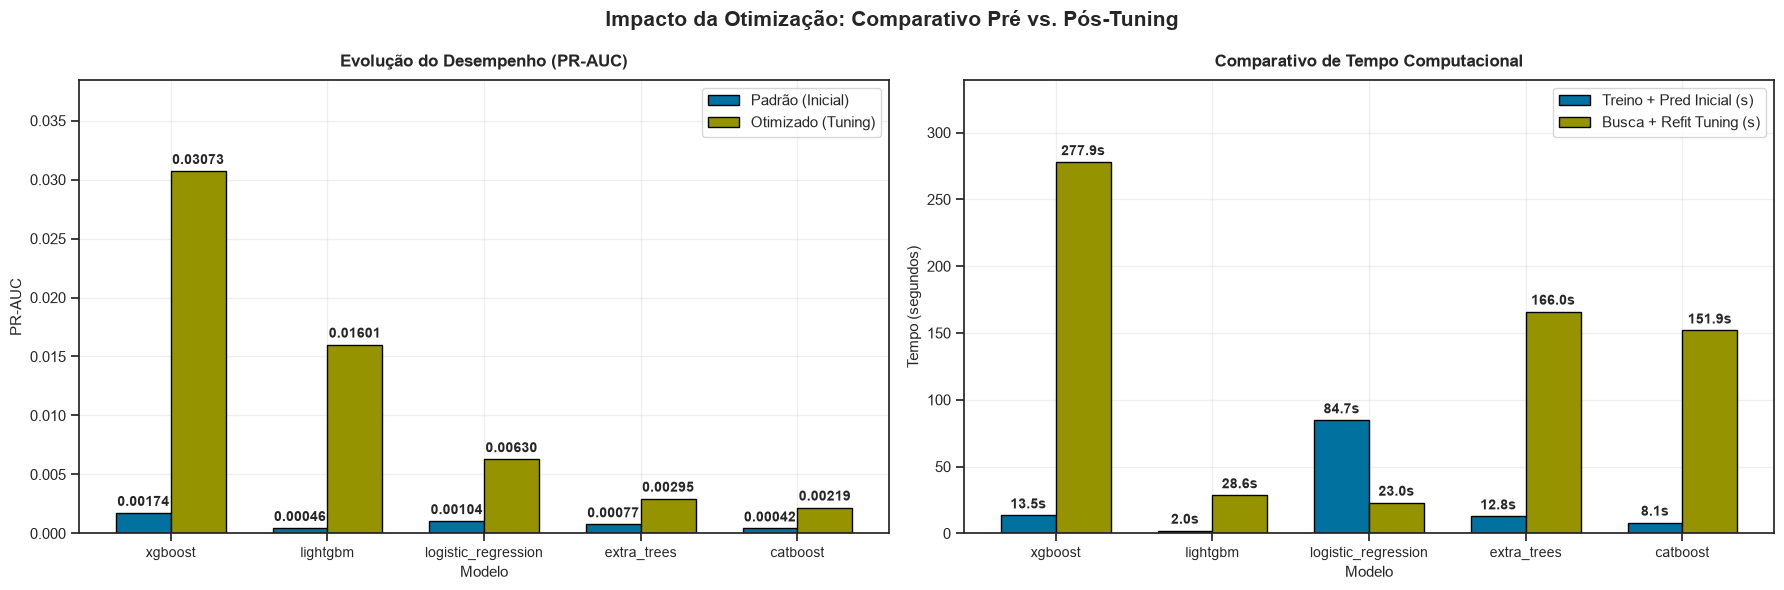

Gráfico salvo com sucesso em: ..\reports\figures\model_tuning_comparative_analysis.png


In [ ]:
# Gráfico comparativo de desempenho e tempo de execução entre modelos pré e pós-tuning

full_path = os.path.join(FIGURES_DIR, "model_tuning_comparative_analysis.png")
relative_path = os.path.relpath(full_path)

df_initial_training = validation_metrics.sort_values(
    "pr_auc",
    ascending=False,
).reset_index(drop=True)

df_prauc_tuned = tuning_summary.sort_values(
    "melhor_pr_auc_cv", ascending=False
).reset_index(drop=True)

df_pr_auc_initial = df_initial_training.copy()
df_pr_auc_initial["tempo_inicial_total_s"] = (
    df_pr_auc_initial["tempo_treino_s"] + df_pr_auc_initial["tempo_pred_s"]
)

data_comp = pd.merge(
    df_pr_auc_initial[["modelo", "pr_auc", "tempo_inicial_total_s"]].rename(
        columns={
            "pr_auc": "pr_auc_inicial",
            "tempo_inicial_total_s": "tempo_inicial_s",
        }
    ),
    tuning_summary[["modelo", "melhor_pr_auc_cv", "tempo_tuning_s"]].rename(
        columns={
            "melhor_pr_auc_cv": "pr_auc_tuned",
        }
    ),
    on="modelo",
)

data_comp = data_comp.sort_values("pr_auc_tuned", ascending=False).reset_index(
    drop=True
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    "Impacto da Otimização: Comparativo Pré vs. Pós-Tuning",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

x = np.arange(len(data_comp["modelo"]))
bar_width = 0.35

rects1_auc = axes[0].bar(
    x - bar_width / 2,
    data_comp["pr_auc_inicial"],
    bar_width,
    label="Padrão (Inicial)",
    color=colors[1],
    edgecolor="black",
)
rects2_auc = axes[0].bar(
    x + bar_width / 2,
    data_comp["pr_auc_tuned"],
    bar_width,
    label="Otimizado (Tuning)",
    color=colors[0],
    edgecolor="black",
)

axes[0].set_ylabel("PR-AUC", fontsize=11)
axes[0].set_xlabel("Modelo", fontsize=11)
axes[0].set_title(
    "Evolução do Desempenho (PR-AUC)", fontweight="bold", fontsize=12, pad=10
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(data_comp["modelo"], rotation=0, fontsize=10)
axes[0].set_ylim(0, data_comp["pr_auc_tuned"].max() * 1.25)
axes[0].legend(loc="upper right", frameon=True)
axes[0].grid(True, alpha=0.3)

for i, row in data_comp.iterrows():
    axes[0].annotate(
        f"{row['pr_auc_inicial']:.5f}",
        (x[i] - bar_width / 2, row["pr_auc_inicial"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

for i, row in data_comp.iterrows():
    axes[0].annotate(
        f"{row['pr_auc_tuned']:.5f}",
        (x[i] + bar_width / 2, row["pr_auc_tuned"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

rects1_time = axes[1].bar(
    x - bar_width / 2,
    data_comp["tempo_inicial_s"],
    bar_width,
    label="Treino + Pred Inicial (s)",
    color=colors[1],
    edgecolor="black",
)
rects2_time = axes[1].bar(
    x + bar_width / 2,
    data_comp["tempo_tuning_s"],
    bar_width,
    label="Busca + Refit Tuning (s)",
    color=colors[0],
    edgecolor="black",
)

axes[1].set_ylabel("Tempo (segundos)", fontsize=11)
axes[1].set_xlabel("Modelo", fontsize=11)
axes[1].set_title(
    "Comparativo de Tempo Computacional",
    fontweight="bold",
    fontsize=12,
    pad=10,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(data_comp["modelo"], rotation=0, fontsize=10)
axes[1].set_ylim(0, data_comp["tempo_tuning_s"].max() * 1.22)
axes[1].legend(loc="upper right", frameon=True)
axes[1].grid(True, alpha=0.3)

for i, row in data_comp.iterrows():
    axes[1].annotate(
        f"{row['tempo_inicial_s']:.1f}s",
        (x[i] - bar_width / 2, row["tempo_inicial_s"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
    axes[1].annotate(
        f"{row['tempo_tuning_s']:.1f}s",
        (x[i] + bar_width / 2, row["tempo_tuning_s"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(relative_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo com sucesso em: {relative_path}")

In [114]:
initial_csv_path = str(INITIAL_RESULTS_FILE)
tuning_csv_path = str(TUNING_RESULTS_FILE)

df_initial = pd.read_csv(initial_csv_path).set_index("modelo")
df_tuning = pd.read_csv(tuning_csv_path).set_index("modelo")

col_pr = "melhor_pr_auc_cv" if "melhor_pr_auc_cv" in df_tuning.columns else "pr_auc_cv"

# 3. Extração dos modelos e métricas
xgb = df_tuning.loc["xgboost"]
lgb = df_tuning.loc["lightgbm"]
lr = df_tuning.loc["logistic_regression"]
et = df_tuning.loc["extra_trees"]
cb = df_tuning.loc["catboost"]

# Ganhos comparativos em relação ao modelo inicial do Tópico 7
ganho_xgb = xgb[col_pr] / max(df_initial.loc["xgboost", "pr_auc"], 1e-8)
ganho_lgb = lgb[col_pr] / max(df_initial.loc["lightgbm", "pr_auc"], 1e-8)

# Piso aleatório baseado na prevalência natural
piso_aleatorio = float(df_initial["pr_auc"].min())
multiplicador_lr = lr[col_pr] / max(piso_aleatorio, 1e-8)

# 4. Exibição dinâmica em Markdown
display(
    Markdown(
        f"* No processo de validação cruzada temporal, o **XGBoost** atingiu o maior valor na predição de transgressões regulatórias, "
        f"com PR-AUC de `{xgb[col_pr]:.8f}`, representando um ganho de cerca de `{ganho_xgb:.0f} vezes` superior ao resultado inicial, "
        f"antes da otimização de hiperparâmetros. A combinação ótima encontrada equilibra a captura de interações não-lineares complexas "
        f"com o controle da variância temporal, apesar de exigir o maior tempo total de execução (**{xgb['tempo_tuning_s']:.2f}s**).\n\n"
        f"* O **LightGBM** garantiu o segundo lugar com `PR-AUC` de `{lgb[col_pr]:.8f}`, um aumento de cerca de **{ganho_lgb:.0f} vezes** "
        f"relativo ao modelo inicial não ajustado, configurando o estimador mais eficiente de todo o conjunto ao concluir todo o processo "
        f"de tuning em apenas **{lgb['tempo_tuning_s']:.2f}s**.\n\n"
        f"* Embora inferior ao XGBoost e LightGBM, a **Regressão Logística**, com a introdução da seleção de variância e do otimizador L-BFGS,"
        f"encerrou a execução em apenas **{lr['tempo_tuning_s']:.2f}s**, atingindo um `PR-AUC` de `{lr[col_pr]:.8f}`, "
        f"o que a coloca cerca de **{multiplicador_lr:.0f} vezes** acima do piso de probabilidade aleatória e confirma"
        f" a sua utilidade como baseline linear.\n\n"
        f"* O **Extra Trees** e **CatBoost**, por sua vez, geraram maiores custos computacionais, porém desempenho inferior. "
        f"O primeiro obteve `PR-AUC` de `{et[col_pr]:.8f}` em **{et['tempo_tuning_s']:.2f}s** e o segundo atingiu `{cb[col_pr]:.8f}`"
        f"em **{cb['tempo_tuning_s']:.2f}s**.\n\n"
        f"* A tabela consolida o **XGBoost** como a escolha primária de modelo para maximizar o cumprimento das metas regulatórias, "
        f"tendo o **LightGBM** como alternativa viável para cenários com forte restrição de recursos computacionais ou retreino frequentes."
    )
)

* No processo de validação cruzada temporal, o **XGBoost** atingiu o maior valor na predição de transgressões regulatórias, com PR-AUC de `0.03072865`, representando um ganho de cerca de `18 vezes` superior ao resultado inicial, antes da otimização de hiperparâmetros. A combinação ótima encontrada equilibra a captura de interações não-lineares complexas com o controle da variância temporal, apesar de exigir o maior tempo total de execução (**277.89s**).

* O **LightGBM** garantiu o segundo lugar com `PR-AUC` de `0.01601176`, um aumento de cerca de **35 vezes** relativo ao modelo inicial não ajustado, configurando o estimador mais eficiente de todo o conjunto ao concluir todo o processo de tuning em apenas **28.59s**.

* Embora inferior ao XGBoost e LightGBM, a **Regressão Logística**, com a introdução da seleção de variância e do otimizador L-BFGS,encerrou a execução em apenas **23.00s**, atingindo um `PR-AUC` de `0.00629618`, o que a coloca cerca de **15 vezes** acima do piso de probabilidade aleatória e confirma a sua utilidade como baseline linear.

* O **Extra Trees** e **CatBoost**, por sua vez, geraram maiores custos computacionais, porém desempenho inferior. O primeiro obteve `PR-AUC` de `0.00294757` em **166.00s** e o segundo atingiu `0.00219453`em **151.87s**.

* A tabela consolida o **XGBoost** como a escolha primária de modelo para maximizar o cumprimento das metas regulatórias, tendo o **LightGBM** como alternativa viável para cenários com forte restrição de recursos computacionais ou retreino frequentes.

---

## 10. Seleção do campeão e validação final  


### 10.1. Calibração do limiar operacional

A calibração do limiar foi conduzida exclusivamente na validação, preservando o conjunto de teste para confirmação final. O critério adotado foi garantir Recall mínimo de 60%, maximizando a precisão operacional.

In [ ]:
# Aplicação do limiar operacional dos modelos selecionados pelo PR-AUC
full_path = OPERATIONAL_RESULTS_FILE
relative_path = os.path.relpath(full_path)

RECALL_FLOOR = 0.60
y_val_arr = np.asarray(
    y_validation.squeeze() if hasattr(y_validation, "squeeze") else y_validation
)

operational_rows = []
operational_predictions = {}
operational_confusion = {}
validation_scores_tuned = {}
calibrated_thresholds = {}

for model_name in tuning_summary["modelo"]:
    model = tuned_models[model_name]
    val_scores = model.predict_proba(X_validation)[:, 1]
    validation_scores_tuned[model_name] = val_scores

    threshold_info = select_decision_threshold(
        y_val_arr,
        val_scores,
        target_recall=RECALL_FLOOR,
        metric="precision",
    )

    tau_star = threshold_info["threshold"]
    calibrated_thresholds[model_name] = tau_star

    preds_bin = (val_scores >= tau_star).astype("int8")
    operational_predictions[model_name] = preds_bin

    conf_mat = confusion_matrix(y_val_arr, preds_bin)
    operational_confusion[model_name] = conf_mat

    metrics = evaluate_classifier(
        model_name,
        y_val_arr,
        preds_bin,
        val_scores,
    )
    metrics["limiar_recall_60"] = tau_star
    metrics["verdadeiros_positivos (TP)"] = int(conf_mat[1, 1])
    metrics["falsos_positivos (FP)"] = int(conf_mat[0, 1])
    metrics["total_alertas"] = int(preds_bin.sum())

    operational_rows.append(metrics)

operational_comparison = (
    pd.DataFrame(operational_rows)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

print("Comparação operacional na validação neutra (Piso de 60% Recall):")
display(
    operational_comparison.style.format(
        {
            "precision": "{:.8f}",
            "recall": "{:.8f}",
            "f1_score": "{:.8f}",
            "roc_auc": "{:.8f}",
            "pr_auc": "{:.8f}",
            "limiar_recall_60": "{:.8f}",
            "verdadeiros_positivos (TP)": "{:d}",
            "falsos_positivos (FP)": "{:d}",
            "total_alertas": "{:d}",
        }
    )
)

operational_comparison.to_csv(
    full_path,
    index=False,
)

print(f"Tabela salva com sucesso em: {relative_path}")

Comparação operacional na validação neutra (Piso de 60% Recall):


,modelo,precision,recall,f1_score,roc_auc,pr_auc,limiar_recall_60,verdadeiros_positivos (TP),falsos_positivos (FP),total_alertas
0,logistic_regression,0.00074906,0.64285714,0.00149638,0.86806869,0.01030154,0.23843337,9,12006,12015
1,catboost,0.00051648,0.85714286,0.00103235,0.81540085,0.00347670,0.04942465,12,23222,23234
2,xgboost,0.00060877,0.64285714,0.00121638,0.76894249,0.00298361,0.00004805,9,14775,14784
3,extra_trees,0.00097965,0.64285714,0.00195631,0.81044183,0.00155145,0.02321026,9,9178,9187
4,lightgbm,0.00026932,0.85714286,0.00053848,0.63184090,0.00025749,1.00000000,12,44544,44556


Tabela salva com sucesso em: ..\docs\metadata\model_operational_comparison.csv


In [116]:
# 1. Caminhos para os arquivos de tuning (CV treino) e comparação operacional (validação)
tuning_csv_path = str(TUNING_RESULTS_FILE)
op_csv_path = str(OPERATIONAL_RESULTS_FILE)
# 2. Leitura dos dados persistidos
df_cv = pd.read_csv(tuning_csv_path).set_index("modelo")

if os.path.exists(op_csv_path):
    df_op = pd.read_csv(op_csv_path).set_index("modelo")
else:
    df_op = operational_comparison.set_index("modelo")

col_cv = "melhor_pr_auc_cv" if "melhor_pr_auc_cv" in df_cv.columns else "pr_auc_cv"

# 3. Extração dos modelos e métricas da calibração operacional
lr = df_op.loc["logistic_regression"]
xgb = df_op.loc["xgboost"]
et = df_op.loc["extra_trees"]
cb = df_op.loc["catboost"]
lgb = df_op.loc["lightgbm"]

xgb_cv_pr = df_cv.loc["xgboost", col_cv]
total_positivos = int(lr["verdadeiros_positivos (TP)"] / lr["recall"])

display(
    Markdown(
        f"* Todos os estimadores superaram a meta regulatória (Recall $\\geq 60$%) na partição neutra de validação.\n\n "
        f"* Embora o **XGBoost** tenha apresentado o maior "
        f"PR-AUC médio no treino cruzado (`{xgb_cv_pr:.8f}`), sofreu degradação na validação temporal (`PR-AUC = {xgb['pr_auc']:.8f}`), "
        f"demandando um limiar extremamente baixo (`{xgb['limiar_recall_60']:.8f}`).\n\n"
        f"* Em contrapartida, a **Regressão Logística** manteve a ordenação mais estável, entregando o maior **PR-AUC ({lr['pr_auc']:.8f})**,"
        f"o maior **ROC-AUC ({lr['roc_auc']:.8f})** e um ponto de corte equilibrado (`limiar = {lr['limiar_recall_60']:.8f}`).\n\n"
        f"* **Regressão Logística**, **XGBoost** e **Extra Trees** alcançaram **{lr['recall']:.2%} de Recall** "
        f"(capturando **{int(lr['verdadeiros_positivos (TP)'])} dos {total_positivos} casos positivos**), "
        f"enquanto **CatBoost** e **LightGBM** entregaram **{cb['recall']:.2%} de Recall** "
        f"(detectando **{int(cb['verdadeiros_positivos (TP)'])} dos {total_positivos} positivos**).\n\n"
        f"* O **Extra Trees** e a **Regressão Logística** demonstraram a maior eficiência de triagem, "
        f"gerando **{int(et['total_alertas']):,}** e **{int(lr['total_alertas']):,} alertas totais** para garantir os"
        f"{lr['recall']:.1%} de cobertura.\n\n "
        f"* No extremo oposto, o **LightGBM** gerou um volume operacional impraticável de **{int(lgb['total_alertas']):,} alertas** "
        f"para capturar as 12 ocorrências (Precisão de apenas **{lgb['precision']:.4%}**, muito próxima do acaso estático)."
    )
)

* Todos os estimadores superaram a meta regulatória (Recall $\geq 60$%) na partição neutra de validação.

 * Embora o **XGBoost** tenha apresentado o maior PR-AUC médio no treino cruzado (`0.03072865`), sofreu degradação na validação temporal (`PR-AUC = 0.00298361`), demandando um limiar extremamente baixo (`0.00004805`).

* Em contrapartida, a **Regressão Logística** manteve a ordenação mais estável, entregando o maior **PR-AUC (0.01030154)**,o maior **ROC-AUC (0.86806869)** e um ponto de corte equilibrado (`limiar = 0.23843337`).

* **Regressão Logística**, **XGBoost** e **Extra Trees** alcançaram **64.29% de Recall** (capturando **9 dos 13 casos positivos**), enquanto **CatBoost** e **LightGBM** entregaram **85.71% de Recall** (detectando **12 dos 13 positivos**).

* O **Extra Trees** e a **Regressão Logística** demonstraram a maior eficiência de triagem, gerando **9,187** e **12,015 alertas totais** para garantir os64.3% de cobertura.

 * No extremo oposto, o **LightGBM** gerou um volume operacional impraticável de **44,556 alertas** para capturar as 12 ocorrências (Precisão de apenas **0.0269%**, muito próxima do acaso estático).

### 10.2 Avaliação final no teste

Com o campeão e o limiar definidos na validação, a etapa final avaliou o modelo em uma janela temporal independente, sem reajuste do limiar. Essa regra garante que a performance reportada no teste reflita a capacidade real de generalização do modelo em dados futuros.

In [132]:
champion_rank = operational_comparison.sort_values(
    ["pr_auc", "precision"],
    ascending=[False, False],
).reset_index(drop=True)

champion_name = champion_rank.loc[0, "modelo"]
champion_threshold = calibrated_thresholds[champion_name]

champion_selection = {
    "modelo_selecionado": champion_name,
    "limiar_validacao": float(champion_threshold),
    "ranking_validacao": champion_rank[
        [
            "modelo",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "limiar_recall_60",
        ]
    ].to_dict(orient="records"),
}

display(Markdown(f"**Campeão pré-selecionado na validação:** {champion_name}"))
display(Markdown(f"**Limiar de validação:** {champion_threshold:.8f}"))

**Campeão pré-selecionado na validação:** logistic_regression

**Limiar de validação:** 0.23843337

In [135]:
# Avaliação final no conjunto de teste com o limiar da validação
model_final = tuned_models[champion_name]
X_test_arr = X_test
y_test_arr = np.asarray(y_test.squeeze() if hasattr(y_test, "squeeze") else y_test)

test_scores = model_final.predict_proba(X_test_arr)[:, 1]
test_predictions = (test_scores >= champion_threshold).astype(int)

test_metrics = evaluate_classifier(
    champion_name,
    y_test_arr,
    test_predictions,
    test_scores,
)

test_confusion = confusion_matrix(y_test_arr, test_predictions)

display(Markdown(f"**Modelo avaliado no teste:** {champion_name}"))
display(Markdown(f"**Limiar utilizado no teste:** {champion_threshold:.8f}"))
display(pd.DataFrame([test_metrics]))
display(
    pd.DataFrame(
        test_confusion,
        index=["real_0", "real_1"],
        columns=["predito_0", "predito_1"],
    )
)

# Persistência do resultado final do teste
final_selection = {
    "modelo_selecionado": champion_name,
    "limiar_validacao": float(champion_threshold),
    "avaliacao_teste": {
        "precision": float(test_metrics["precision"]),
        "recall": float(test_metrics["recall"]),
        "f1_score": float(test_metrics["f1_score"]),
        "roc_auc": float(test_metrics["roc_auc"]),
        "pr_auc": float(test_metrics["pr_auc"]),
    },
    "matriz_confusao": test_confusion.tolist(),
}

final_evaluation_path = MODEL_DIR / "model_selected.joblib"
joblib.dump(final_selection, final_evaluation_path)

relative_path = os.path.relpath(MODEL_DIR)

print(f"\nAvaliação final do modelo campeão persistida com sucesso em: {relative_path}")

**Modelo avaliado no teste:** logistic_regression

**Limiar utilizado no teste:** 0.23843337

,modelo,precision,recall,f1_score,roc_auc,pr_auc
0,logistic_regression,0.00034973,0.50000000,0.00069897,0.87539602,0.00062382


,predito_0,predito_1
real_0,60445,8575
real_1,3,3



Avaliação final do modelo campeão persistida com sucesso em: ..\models


---

## 11. Limitações e conclusão

* O número de transgressões ainda é pequeno, o que torna a precisão operacional sensível a variações temporais.

* O trade-off entre Recall e precisão continua presente: aumentar a cobertura tende a elevar o número de alertas falsos.

* O próximo passo é aplicar o modelo campeão em produção em uma janela operacional real, monitorando a estabilidade do limiar ao longo do tempo.

* A estratégia de corte deve ser revisada periodicamente conforme o custo de falsos positivos e a criticidade regulatória.

* A etapa de modelagem confirmou que o desbalanceamento do problema exigiu avaliação orientada por métricas de classe positiva, especialmente **PR-AUC**, **Recall** e **Precisão operacional**.

* O ajuste temporal de hiperparâmetros foi essencial para melhorar o desempenho dos candidatos e reduzir a dependência do limiar padrão de **0,50**.

* O modelo vencedor foi persistido junto com o limiar operacional e os metadados do experimento, tornando a solução reproduzível e pronta para uso em inferência ou etapas subsequentes do projeto.